# TimeSformer Temporal Order Prediction Training

**NEW APPROACH: Pairwise Temporal Order Prediction**

Based on "Shuffle and Learn" (Misra & van der Heijden, ECCV 2016)

**Task:**
- Given 2 frames from a sequence, predict if they are in correct temporal order
- Binary classification: 1 = correct order, 0 = swapped

**Why this works better than MAE:**
- Directly learns temporal relationships (not pixel reconstruction)
- Different typologies have different temporal progressions
- More training signal: 3 pairs per sequence × 10,474 sequences = ~31K training samples
- No geometry-changing augmentations needed!

**Expected result:** Better clustering! (Silhouette > 0, ARI > 0.3)

## Setup

In [1]:
import os
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import time
from datetime import datetime

from config import get_mae_config  # Reuse config but adapt for 2 frames
from timesformer_temporal_order import TimeSformerTemporalOrder
from dataset_temporal_order import create_dataloaders

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU available, using CPU")

GPU: NVIDIA GeForce RTX 5060 Laptop GPU


## Configuration

In [2]:
# ============================================================================
# DATA & MODEL SETTINGS
# ============================================================================
DATA_ROOT = r"C:\Users\shrua\OneDrive\Desktop\threshold project\threshold\data"

# ============================================================================
# TRAINING HYPERPARAMETERS
# ============================================================================
NUM_EPOCHS = 10  # Temporal order usually converges faster than MAE
BATCH_SIZE = 32  # Can use larger batch since we only process 2 frames
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.05
TRAIN_SPLIT = 0.85

# How many pairs to generate per sequence (more = more training data)
PAIRS_PER_SEQUENCE = 3

# ============================================================================
# SYSTEM SETTINGS
# ============================================================================
NUM_WORKERS = 0
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

OUTPUT_DIR = r"C:\Users\shrua\OneDrive\Desktop\threshold project\threshold\models\output_temporal_order"
SAVE_FREQ = 5  # Save checkpoint every N epochs

# ============================================================================
# PRINT CONFIGURATION
# ============================================================================
print("="*80)
print("TEMPORAL ORDER PREDICTION TRAINING")
print("="*80)
print(f"Task:           Pairwise temporal order classification")
print(f"Epochs:         {NUM_EPOCHS}")
print(f"Batch size:     {BATCH_SIZE}")
print(f"Learning rate:  {LEARNING_RATE}")
print(f"Pairs/seq:      {PAIRS_PER_SEQUENCE}")
print(f"Device:         {DEVICE}")
print(f"Output dir:     {OUTPUT_DIR}")
print("="*80)

TEMPORAL ORDER PREDICTION TRAINING
Task:           Pairwise temporal order classification
Epochs:         10
Batch size:     32
Learning rate:  0.0001
Pairs/seq:      3
Device:         cuda
Output dir:     C:\Users\shrua\OneDrive\Desktop\threshold project\threshold\models\output_temporal_order


In [3]:
# Create output directories
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, 'checkpoints'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, 'visualizations'), exist_ok=True)
print(f"✓ Output directories created")

✓ Output directories created


## Load Data

In [4]:
print("Loading dataset...")

train_loader, val_loader = create_dataloaders(
    data_root=DATA_ROOT,
    batch_size=BATCH_SIZE,
    train_split=TRAIN_SPLIT,
    num_workers=NUM_WORKERS,
    pairs_per_sequence=PAIRS_PER_SEQUENCE,
)

print(f"✓ Data loaded")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Train pairs: {len(train_loader.dataset)}")
print(f"  Val pairs: {len(val_loader.dataset)}")

Loading dataset...
Found 32 threshold CSV files
Train CSVs: 27, Val CSVs: 5
Loaded 6867 threshold sequences from 27 files
Generated 20601 frame pairs (3 per sequence)
Loaded 1215 threshold sequences from 5 files
Generated 3645 frame pairs (3 per sequence)
Train pairs: 20601, Val pairs: 3645
✓ Data loaded
  Train batches: 644
  Val batches: 114
  Train pairs: 20601
  Val pairs: 3645


## Inspect Data Sample

Sample batch:
  Frames shape: torch.Size([32, 2, 3, 32, 64])
  Labels shape: torch.Size([32])
  Labels: [0, 1, 0, 1, 1, 1, 1, 0]
  Typology labels: [0, 5, 1, 5, 3, 6, 0, 5]


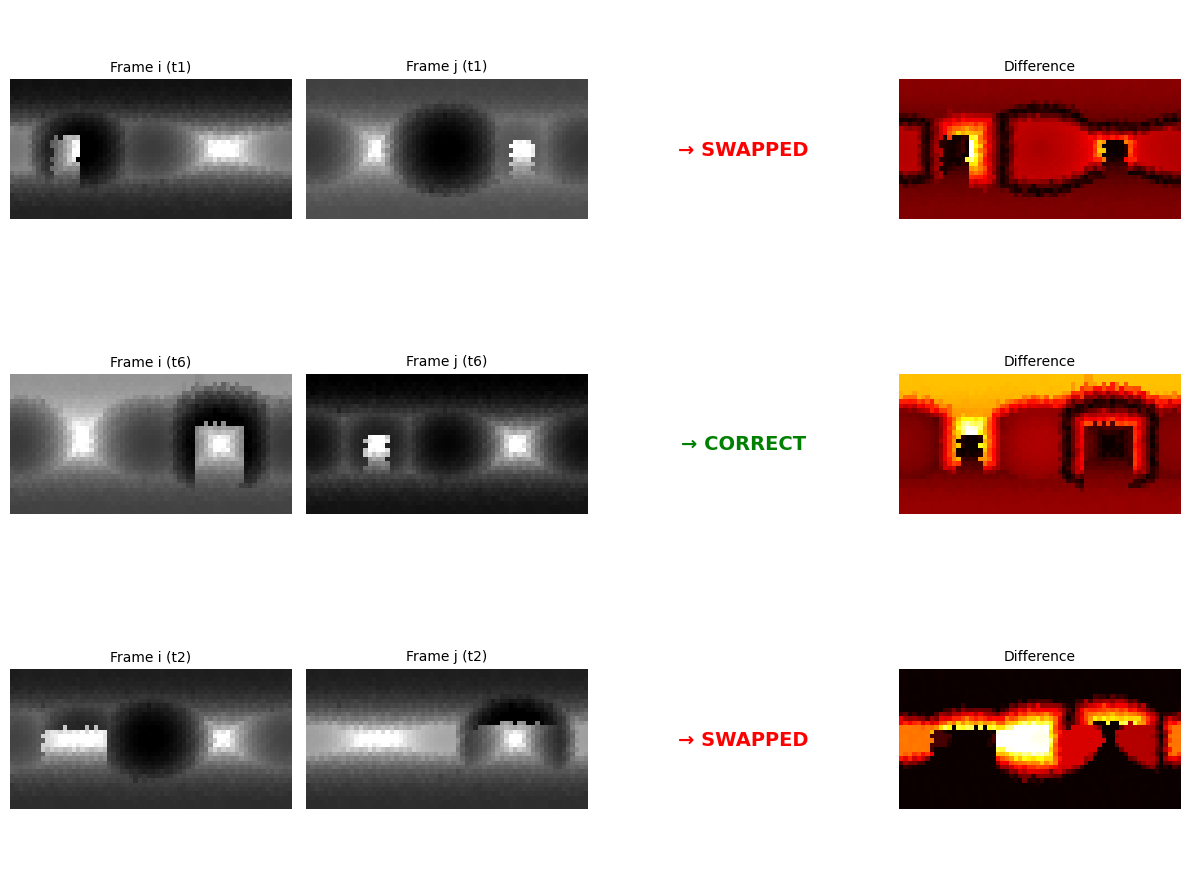


✓ Sample pairs visualized


In [5]:
# Get a sample batch
sample_batch = next(iter(train_loader))

print(f"Sample batch:")
print(f"  Frames shape: {sample_batch['frames'].shape}")  # (B, 2, 3, 32, 64)
print(f"  Labels shape: {sample_batch['labels'].shape}")  # (B,)
print(f"  Labels: {sample_batch['labels'][:8].tolist()}")  # First 8 labels
print(f"  Typology labels: {sample_batch['typology_labels'][:8].tolist()}")

# Visualize a few pairs
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for i in range(3):
    frames = sample_batch['frames'][i]  # (2, 3, 32, 64)
    label = sample_batch['labels'][i].item()
    typo_label = sample_batch['typology_labels'][i].item()
    
    # Frame i (first frame)
    frame_i = frames[0].permute(1, 2, 0).numpy()  # (32, 64, 3)
    axes[i, 0].imshow(frame_i, cmap='gray')
    axes[i, 0].set_title(f'Frame i (t{typo_label+1})', fontsize=10)
    axes[i, 0].axis('off')
    
    # Frame j (second frame)
    frame_j = frames[1].permute(1, 2, 0).numpy()  # (32, 64, 3)
    axes[i, 1].imshow(frame_j, cmap='gray')
    axes[i, 1].set_title(f'Frame j (t{typo_label+1})', fontsize=10)
    axes[i, 1].axis('off')
    
    # Arrow showing order
    order_text = "→ CORRECT" if label == 1 else "→ SWAPPED"
    color = 'green' if label == 1 else 'red'
    axes[i, 2].text(0.5, 0.5, order_text, fontsize=14, fontweight='bold',
                   ha='center', va='center', color=color)
    axes[i, 2].axis('off')
    
    # Depth difference (simple visualization)
    diff = np.abs(frame_i - frame_j).mean(axis=-1)
    axes[i, 3].imshow(diff, cmap='hot')
    axes[i, 3].set_title('Difference', fontsize=10)
    axes[i, 3].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'visualizations', 'sample_pairs.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Sample pairs visualized")

## Create Model

In [6]:
# Get config (same architecture, but we'll use it for 2-frame input)
config = get_mae_config()

# IMPORTANT: Override num_frames to 2 for pairwise input
config.num_frames = 2
config.total_patches = config.num_frames * config.num_patches_per_frame

print(f"Adapted config for temporal order:")
print(f"  Frames: {config.num_frames} (2 frames per pair)")
print(f"  Total patches: {config.total_patches}")

# Create model
model = TimeSformerTemporalOrder(config)
model = model.to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✓ Model created")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Encoder parameters: {sum(p.numel() for p in model.encoder.parameters()):,}")
print(f"  Classifier parameters: {sum(p.numel() for p in model.classifier.parameters()):,}")

Configuration:
  Image size: 32x64
  Patch size: 4x4
  Patches per frame: 128 (8x16)
  Total frames: 7
  Total patches: 896
  Visible patches (~10%): ~89
  Masked patches (~90%): ~806
Adapted config for temporal order:
  Frames: 2 (2 frames per pair)
  Total patches: 256

✓ Model created
  Total parameters: 14,461,825
  Trainable parameters: 14,461,825
  Encoder parameters: 14,313,600
  Classifier parameters: 148,225


## Setup Training

In [7]:
# Loss function: Binary Cross Entropy with Logits
criterion = nn.BCEWithLogitsLoss()

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.95),
)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=LEARNING_RATE * 0.01,
)

print("✓ Optimizer and scheduler created")

✓ Optimizer and scheduler created


In [8]:
# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'learning_rate': [],
    'epoch_time': [],
}

best_val_acc = 0.0

## Training Functions

In [9]:
def train_one_epoch(model, dataloader, criterion, optimizer, device, epoch):
    """
    Train for one epoch.
    """
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    pbar = tqdm(dataloader, desc=f"Epoch {epoch} [Train]")
    
    for batch in pbar:
        frames = batch['frames'].to(device)  # (B, 2, 3, 32, 64)
        labels = batch['labels'].to(device).float()  # (B,)
        
        # Forward pass
        logits = model(frames).squeeze(1)  # (B,)
        loss = criterion(logits, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Calculate accuracy
        preds = (torch.sigmoid(logits) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        # Accumulate loss
        total_loss += loss.item()
        
        # Update progress bar
        acc = correct / total
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{acc:.3f}'})
    
    avg_loss = total_loss / len(dataloader)
    avg_acc = correct / total
    return avg_loss, avg_acc


def validate(model, dataloader, criterion, device, epoch):
    """
    Validate the model.
    """
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc=f"Epoch {epoch} [Val]")
        
        for batch in pbar:
            frames = batch['frames'].to(device)
            labels = batch['labels'].to(device).float()
            
            logits = model(frames).squeeze(1)
            loss = criterion(logits, labels)
            
            # Calculate accuracy
            preds = (torch.sigmoid(logits) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            total_loss += loss.item()
            acc = correct / total
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{acc:.3f}'})
    
    avg_loss = total_loss / len(dataloader)
    avg_acc = correct / total
    return avg_loss, avg_acc


def save_checkpoint(model, optimizer, epoch, val_acc, filename):
    """
    Save model checkpoint.
    """
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_acc': val_acc,
    }
    torch.save(checkpoint, filename)
    print(f"  Saved: {os.path.basename(filename)}")

## TRAINING LOOP

In [10]:
print("="*80)
print(f"STARTING TRAINING: {NUM_EPOCHS} epochs")
print("="*80)
print(f"Start time: {datetime.now().strftime('%H:%M:%S')}")
print()

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()
    
    # Train
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, epoch)
    
    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, DEVICE, epoch)
    
    # Update scheduler
    scheduler.step()
    
    # Record history
    epoch_time = time.time() - epoch_start
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['learning_rate'].append(optimizer.param_groups[0]['lr'])
    history['epoch_time'].append(epoch_time)
    
    # Print epoch summary
    print(f"\nEpoch {epoch}/{NUM_EPOCHS-1}")
    print(f"  Train Loss: {train_loss:.4f}  |  Train Acc: {train_acc:.3f}")
    print(f"  Val Loss:   {val_loss:.4f}  |  Val Acc:   {val_acc:.3f}")
    print(f"  LR:         {optimizer.param_groups[0]['lr']:.6f}")
    print(f"  Time:       {epoch_time:.1f}s")
    
    # Save checkpoint
    if (epoch + 1) % SAVE_FREQ == 0:
        checkpoint_path = os.path.join(
            OUTPUT_DIR, 'checkpoints', f'checkpoint_epoch_{epoch:04d}.pt'
        )
        save_checkpoint(model, optimizer, epoch, val_acc, checkpoint_path)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_path = os.path.join(OUTPUT_DIR, 'checkpoints', 'best_model.pt')
        save_checkpoint(model, optimizer, epoch, val_acc, best_path)
        print(f"  ⭐ New best model! (val_acc: {val_acc:.3f})")
    
    print("-" * 80)

print("\n" + "="*80)
print("TRAINING COMPLETE!")
print("="*80)
print(f"End time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Best validation accuracy: {best_val_acc:.3f}")
print(f"Total time: {sum(history['epoch_time'])/60:.1f} minutes")

STARTING TRAINING: 10 epochs
Start time: 01:34:38



Epoch 0 [Train]:   0%|          | 0/644 [00:00<?, ?it/s]

Epoch 0 [Val]:   0%|          | 0/114 [00:00<?, ?it/s]


Epoch 0/9
  Train Loss: 0.4104  |  Train Acc: 0.746
  Val Loss:   0.0940  |  Val Acc:   0.977
  LR:         0.000098
  Time:       157.0s
  Saved: best_model.pt
  ⭐ New best model! (val_acc: 0.977)
--------------------------------------------------------------------------------


Epoch 1 [Train]:   0%|          | 0/644 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Save Final Model

In [11]:
# Save final model
final_path = os.path.join(OUTPUT_DIR, 'checkpoints', 'final_model.pt')
save_checkpoint(model, optimizer, NUM_EPOCHS - 1, history['val_acc'][-1], final_path)

# Save encoder only (for clustering)
encoder_path = os.path.join(OUTPUT_DIR, 'timesformer_encoder_temporal_order.pt')
torch.save({
    'config': config,
    'encoder_state_dict': model.encoder.state_dict(),
}, encoder_path)

print(f"\n✓ Pretrained encoder saved: {encoder_path}")
print("\n⭐ Use this encoder for clustering evaluation (next step)")

  Saved: final_model.pt

✓ Pretrained encoder saved: C:\Users\shrua\OneDrive\Desktop\threshold project\threshold\models\output_temporal_order\timesformer_encoder_temporal_order.pt

⭐ Use this encoder for clustering evaluation (next step)


## Visualize Training Results

Loading BEST model for visualization...
✓ Loaded best model from epoch 0
  Val Acc: 0.977



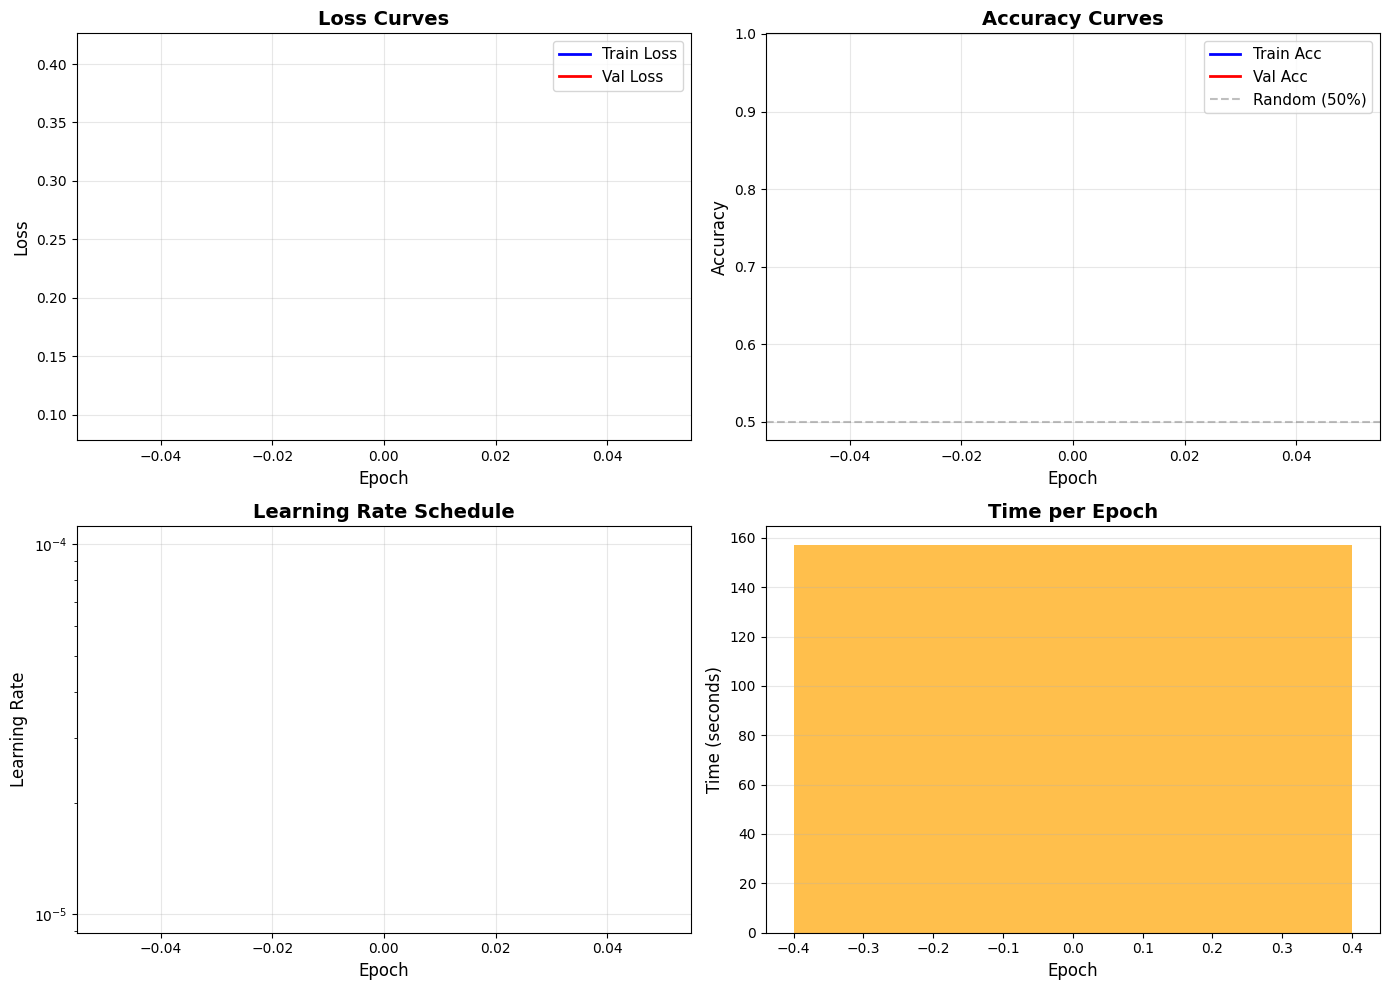


✓ Training curves saved


In [11]:
print("Loading BEST model for visualization...")

# Load best checkpoint
BEST_CHECKPOINT = os.path.join(OUTPUT_DIR, 'checkpoints', 'best_model.pt')
checkpoint = torch.load(BEST_CHECKPOINT, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(DEVICE)
model.eval()

print(f"✓ Loaded best model from epoch {checkpoint['epoch']}")
print(f"  Val Acc: {checkpoint['val_acc']:.3f}")
print()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs_range = range(len(history['train_loss']))

# Plot 1: Loss curves
axes[0, 0].plot(epochs_range, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0, 0].plot(epochs_range, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Loss Curves', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Accuracy curves
axes[0, 1].plot(epochs_range, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
axes[0, 1].plot(epochs_range, history['val_acc'], 'r-', label='Val Acc', linewidth=2)
axes[0, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (50%)')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Accuracy', fontsize=12)
axes[0, 1].set_title('Accuracy Curves', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Learning rate
axes[1, 0].plot(epochs_range, history['learning_rate'], 'g-', linewidth=2)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Learning Rate', fontsize=12)
axes[1, 0].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_yscale('log')

# Plot 4: Time per epoch
axes[1, 1].bar(epochs_range, history['epoch_time'], color='orange', alpha=0.7)
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Time (seconds)', fontsize=12)
axes[1, 1].set_title('Time per Epoch', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Training curves saved")

## T-SNE Clustering Analysis

**Key Question:** Does temporal order prediction lead to better clustering than MAE?

EXTRACTING EMBEDDINGS FROM VALIDATION SET
Found 32 threshold CSV files
Loaded 8082 threshold sequences from 32 files
Train size: 6869, Val size: 1213
Loaded 1213 full sequences for clustering

Configuration:
  Image size: 32x64
  Patch size: 4x4
  Patches per frame: 128 (8x16)
  Total frames: 7
  Total patches: 896
  Visible patches (~10%): ~89
  Masked patches (~90%): ~806
✓ Interpolated positional embeddings: 256 → 896
✓ Created 7-frame encoder with transferred weights



Extracting embeddings:   0%|          | 0/38 [00:00<?, ?it/s]

✓ Extracted 1213 embeddings
  Embedding dimension: 384

Computing t-SNE projection...
✓ t-SNE complete

Computing k-means clustering...
✓ K-means complete

Clustering Metrics:
  Silhouette Score: -0.131 (higher is better, range: -1 to 1)
  Adjusted Rand Index: 0.085 (1.0 = perfect match with ground truth)

Comparison with MAE:
  MAE Silhouette: -0.098 (poor clustering)
  Temporal Order Silhouette: -0.131
  ✗ Still poor



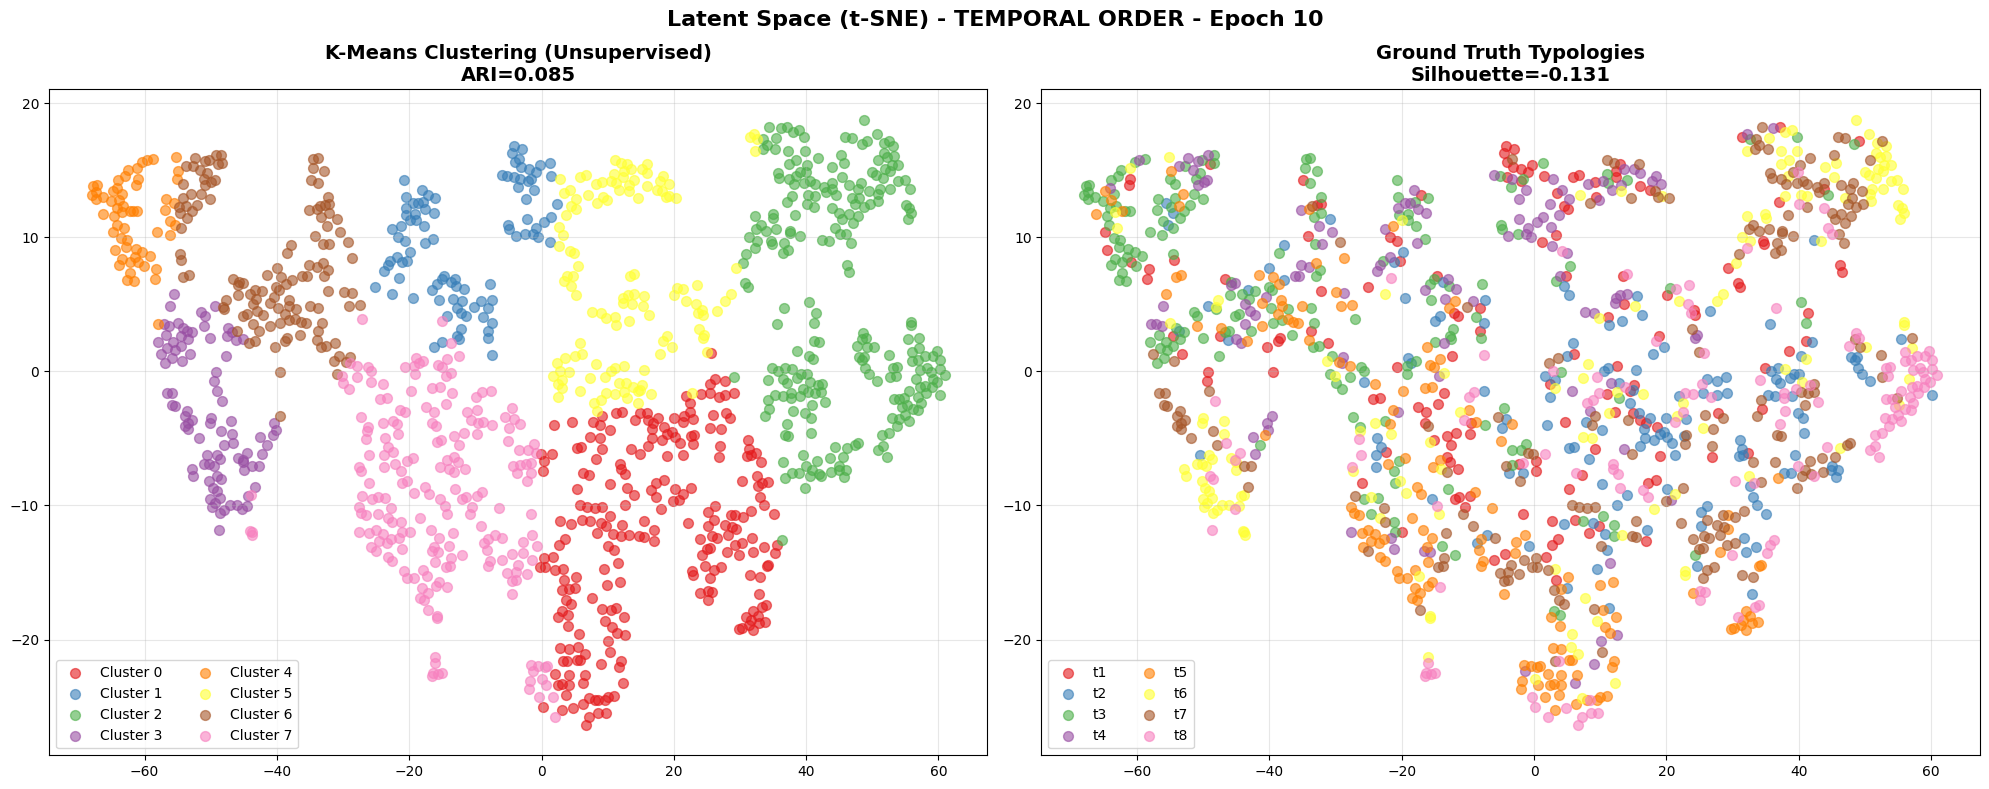


CLUSTER PURITY ANALYSIS

Cluster | Size | Dominant | Purity | Distribution
--------------------------------------------------------------------------------
   0    |  244 |    t2   | 22.1%  | t1:26, t2:54, t3:7, t4:7, t5:44, t6:20, t7:53, t8:33
   1    |   95 |    t3   | 29.5%  | t1:22, t2:7, t3:28, t4:28, t5:4, t6:2, t7:2, t8:2
   2    |  250 |    t7   | 30.8%  | t1:15, t2:33, t3:5, t4:1, t5:1, t6:57, t7:77, t8:61
   3    |   93 |    t6   | 30.1%  | t1:5, t2:4, t3:17, t4:8, t5:4, t6:28, t7:19, t8:8
   4    |   60 |    t3   | 65.0%  | t1:7, t2:2, t3:39, t4:3, t5:5, t6:4
   5    |  129 |    t4   | 24.0%  | t1:29, t2:20, t3:9, t4:31, t6:14, t7:12, t8:14
   6    |  128 |    t3   | 39.8%  | t1:14, t2:6, t3:51, t4:27, t5:25, t6:3, t7:2
   7    |  214 |    t5   | 30.4%  | t1:29, t2:17, t3:29, t4:10, t5:65, t6:23, t7:25, t8:16


In [12]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

print("="*80)
print("EXTRACTING EMBEDDINGS FROM VALIDATION SET")
print("="*80)

# For clustering, we need to encode FULL 7-frame sequences
# Create a NEW encoder with 7-frame positional embeddings
from dataset import create_dataloaders as create_full_dataloaders

# Load full sequences for clustering
_, val_full_loader = create_full_dataloaders(
    data_root=DATA_ROOT,
    batch_size=BATCH_SIZE,
    train_split=TRAIN_SPLIT,
    num_workers=NUM_WORKERS,
)

print(f"Loaded {len(val_full_loader.dataset)} full sequences for clustering")
print()

# Create a new encoder config for 7 frames
from config import get_mae_config
from timesformer_mae import TimeSformerEncoder

full_config = get_mae_config()
full_config.num_frames = 7
full_config.total_patches = full_config.num_frames * full_config.num_patches_per_frame

# Create new encoder with 7-frame positional embeddings
encoder_7frame = TimeSformerEncoder(full_config).to(DEVICE)

# Copy trained weights from the 2-frame encoder (except pos_embed)
trained_state = model.encoder.state_dict()
new_state = encoder_7frame.state_dict()

for name, param in trained_state.items():
    if name == 'pos_embed':
        # Interpolate positional embeddings from 256 to 896
        # Method: repeat and interpolate
        old_pos = param  # (1, 256, D)
        new_pos = new_state['pos_embed']  # (1, 896, D)
        
        # Simple approach: interpolate using torch.nn.functional
        import torch.nn.functional as F
        old_pos_reshaped = old_pos.permute(0, 2, 1)  # (1, D, 256)
        new_pos_interpolated = F.interpolate(
            old_pos_reshaped, 
            size=896, 
            mode='linear', 
            align_corners=False
        )
        new_pos_interpolated = new_pos_interpolated.permute(0, 2, 1)  # (1, 896, D)
        encoder_7frame.state_dict()['pos_embed'].copy_(new_pos_interpolated)
        print(f"✓ Interpolated positional embeddings: 256 → 896")
    else:
        # Copy other parameters directly
        if name in new_state and param.shape == new_state[name].shape:
            new_state[name].copy_(param)

encoder_7frame.load_state_dict(new_state)
print(f"✓ Created 7-frame encoder with transferred weights")
print()

# Extract embeddings
all_embeddings = []
all_labels = []

encoder_7frame.eval()
with torch.no_grad():
    for i, batch in enumerate(tqdm(val_full_loader, desc="Extracting embeddings")):
        pixel_values = batch['pixel_values'].to(DEVICE)  # (B, 7, 3, 32, 64)
        labels = batch['labels'].numpy()
        
        # Get embeddings from the 7-frame encoder
        latent = encoder_7frame(pixel_values)  # This now works!
        latent_pooled = latent.mean(dim=1)  # Pool across patches
        
        all_embeddings.append(latent_pooled.cpu().numpy())
        all_labels.append(labels)

embeddings = np.concatenate(all_embeddings)
labels = np.concatenate(all_labels)

print(f"✓ Extracted {len(embeddings)} embeddings")
print(f"  Embedding dimension: {embeddings.shape[1]}")
print()

# t-SNE projection
print("Computing t-SNE projection...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
embeddings_2d = tsne.fit_transform(embeddings)
print("✓ t-SNE complete")
print()

# K-means clustering
print("Computing k-means clustering...")
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
clusters = kmeans.fit_predict(embeddings)
print("✓ K-means complete")
print()

# Calculate metrics
silhouette = silhouette_score(embeddings_2d, labels)
ari = adjusted_rand_score(labels, clusters)

print(f"Clustering Metrics:")
print(f"  Silhouette Score: {silhouette:.3f} (higher is better, range: -1 to 1)")
print(f"  Adjusted Rand Index: {ari:.3f} (1.0 = perfect match with ground truth)")
print()
print(f"Comparison with MAE:")
print(f"  MAE Silhouette: -0.098 (poor clustering)")
print(f"  Temporal Order Silhouette: {silhouette:.3f}")
print(f"  {'✓ IMPROVEMENT!' if silhouette > -0.098 else '✗ Still poor'}")
print()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', 
          '#ff7f00', '#ffff33', '#a65628', '#f781bf']

# Left: K-means clusters
for i in range(8):
    mask = clusters == i
    axes[0].scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
                   c=colors[i], label=f'Cluster {i}', alpha=0.6, s=50)
axes[0].set_title(f'K-Means Clustering (Unsupervised)\nARI={ari:.3f}', 
                  fontsize=14, fontweight='bold')
axes[0].legend(ncol=2)
axes[0].grid(alpha=0.3)

# Right: Ground truth
for i in range(8):
    mask = labels == i
    if mask.sum() > 0:
        axes[1].scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
                       c=colors[i], label=f't{i+1}', alpha=0.6, s=50)
axes[1].set_title(f'Ground Truth Typologies\nSilhouette={silhouette:.3f}', 
                  fontsize=14, fontweight='bold')
axes[1].legend(ncol=2)
axes[1].grid(alpha=0.3)

plt.suptitle(f'Latent Space (t-SNE) - TEMPORAL ORDER - Epoch {NUM_EPOCHS}', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'tsne_clustering.png'), dpi=300, bbox_inches='tight')
plt.show()

# Cluster purity
print("\n" + "="*80)
print("CLUSTER PURITY ANALYSIS")
print("="*80)
print(f"\nCluster | Size | Dominant | Purity | Distribution")
print("-" * 80)
for i in range(8):
    mask = clusters == i
    cluster_types = labels[mask]
    if len(cluster_types) > 0:
        unique, counts = np.unique(cluster_types, return_counts=True)
        dominant = unique[np.argmax(counts)]
        purity = counts.max() / len(cluster_types)
        dist = ", ".join([f"t{u+1}:{c}" for u, c in zip(unique, counts)])
        print(f"   {i}    | {len(cluster_types):4d} |    t{dominant+1}   | {purity:5.1%}  | {dist}")

print("="*80)

## Training Statistics

In [ ]:
print("="*80)
print("TRAINING STATISTICS")
print("="*80)
print(f"\nFinal Results:")
print(f"  Final Train Acc: {history['train_acc'][-1]:.3f}")
print(f"  Final Val Acc:   {history['val_acc'][-1]:.3f}")
print(f"  Best Val Acc:    {best_val_acc:.3f} (epoch {np.argmax(history['val_acc'])})")

print(f"\nImprovement:")
print(f"  Initial Acc: {history['val_acc'][0]:.3f} (random ~0.5)")
print(f"  Final Acc:   {history['val_acc'][-1]:.3f}")
print(f"  Gain:        {(history['val_acc'][-1] - 0.5)*100:.1f} percentage points above random")

print(f"\nTiming:")
print(f"  Total time:       {sum(history['epoch_time'])/60:.1f} minutes")
print(f"  Avg time/epoch:   {np.mean(history['epoch_time']):.1f} seconds")

print(f"\nOutput Files:")
print(f"  Best model:        {os.path.join(OUTPUT_DIR, 'checkpoints', 'best_model.pt')}")
print(f"  Encoder:           {os.path.join(OUTPUT_DIR, 'timesformer_encoder_temporal_order.pt')}")
print("="*80)

## Next Steps

1. **Compare clustering**: Check if Silhouette/ARI improved vs MAE
2. **If still poor**: Try different frame sampling strategies or increase pairs_per_sequence
3. **If good**: Use this encoder for downstream tasks

The pretrained encoder is saved in:
```
output_temporal_order/timesformer_encoder_temporal_order.pt
```